# Football-LLM · Notebook 4 · Scaling Ablation + Distribution Analysis

**ECE 590.09 Final Project · Zanwen Fu**

Trains three additional QLoRA adapters at **n = 48, 96, 192** using identical hyperparameters to `train_colab.ipynb`. Combined with the existing n=384 adapter (`zanwenfu/football-llm-qlora`), produces the four-point scaling curve.

Each adapter is then evaluated on the full 128-sample 2022 eval set and broken down by **named vs. anonymized**.

**This version also tracks prediction distributions** (home/draw/away rate) across conditions — the central finding from the ICL/CoT analysis was that gradient-free methods collapse to near-100% home_win prediction. The scaling ablation will reveal *at what n* FT escapes this collapse, which is the paper's headline result.

**Runtime on T4:**
- n=48:  ~10 min train + 8 min eval
- n=96:  ~18 min train + 8 min eval
- n=192: ~35 min train + 8 min eval
- n=384: ~8 min eval only (adapter already exists)
- Total: ~90 minutes. **Resumable** — re-running skips completed adapters and evals.

**Outputs (in `/content/`):**
- `runs/qlora_n48/`, `runs/qlora_n96/`, `runs/qlora_n192/` — LoRA adapters
- `scaling_eval_n{N}.json` — full raw predictions with is_anon tags
- `scaling_metrics.json` — summary with prediction distributions
- `scaling_curve.png` — accuracy × data budget
- `distribution_curve.png` — home/draw/away prediction rate × data budget
- `loss_curves.png` — train/val overfitting diagnostic


## 1. Setup

In [1]:
# DO NOT force-install PyTorch — Colab's version is matched to CUDA drivers.
%pip install -q tensorboard matplotlib
%pip install -q --upgrade transformers datasets accelerate bitsandbytes trl peft hf-transfer

import importlib
for pkg in ['torch', 'transformers', 'trl', 'peft', 'bitsandbytes', 'accelerate', 'datasets']:
    print(f"{pkg}: {importlib.import_module(pkg).__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 132.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.2 MB/s eta 0:00:00
torch: 2.10.0+cu128
transformers: 5.5.4
trl: 1.2.0
peft: 0.19.1
bitsandbytes: 0.49.2
accelerate: 1.13.0
datasets: 4.8.4


In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [3]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
VRAM: 15.6 GB


## 2. Clone data and build nested stratified splits

Nested stratified splits at n = 48, 96, 192 drawn from the 192 named training matches. n=384 uses the existing n=192 named + 192 anonymized training data (the configuration of the existing `zanwenfu/football-llm-qlora` adapter).


In [4]:
import os, json, random, re
import numpy as np

!rm -rf football-llm && git clone https://github.com/zanwenfu/football-llm.git

def load_jsonl(p):
    with open(p) as f:
        return [json.loads(l) for l in f]

def save_jsonl(samples, p):
    with open(p, "w") as f:
        for s in samples:
            f.write(json.dumps(s) + "\n")

full_train = load_jsonl("football-llm/data/training/train.jsonl")
full_eval  = load_jsonl("football-llm/data/training/eval.jsonl")
print(f"Full train: {len(full_train)} | Full eval: {len(full_eval)}")

train_named, train_anon = [], []
for s in full_train:
    if 'Team A' in s['messages'][1]['content'] and 'Team B' in s['messages'][1]['content']:
        train_anon.append(s)
    else:
        train_named.append(s)
print(f"Named: {len(train_named)} | Anon: {len(train_anon)}")

Cloning into 'football-llm'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (187/187), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 187 (delta 24), reused 181 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (187/187), 13.54 MiB | 3.91 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Full train: 384 | Full eval: 128
Named: 192 | Anon: 192


In [5]:
def gt_label(sample):
    """Extract home_win/away_win/draw from assistant message."""
    text = sample['messages'][2]['content'].lower()
    m = re.search(r'(\d+)\s*[-\u2013]\s*(\d+)', text)
    if m:
        h, a = int(m.group(1)), int(m.group(2))
        if h > a: return 'home_win'
        if h < a: return 'away_win'
        return 'draw'
    for lbl in ['home_win', 'away_win', 'draw']:
        if lbl in text:
            return lbl
    return None


from collections import defaultdict
buckets = defaultdict(list)
for i, s in enumerate(train_named):
    lbl = gt_label(s)
    if lbl:
        buckets[lbl].append(i)
print("Named train by outcome:", {k: len(v) for k, v in buckets.items()})

random.seed(42)
shuffled = {k: random.sample(v, len(v)) for k, v in buckets.items()}
total = sum(len(v) for v in shuffled.values())

def take_prefix(n_total):
    picks = []
    for lbl, idxs in shuffled.items():
        k = round(n_total * len(idxs) / total)
        picks.extend(idxs[:k])
    picks = sorted(set(picks))
    while len(picks) < n_total:
        for lbl in sorted(shuffled, key=lambda x: -len(shuffled[x])):
            for i in shuffled[lbl]:
                if i not in picks:
                    picks.append(i)
                    break
            if len(picks) >= n_total:
                break
    return sorted(picks[:n_total])

splits = {}
for n in [48, 96, 192]:
    idxs = take_prefix(n)
    splits[n] = idxs
    c = {lbl: sum(1 for i in idxs if i in buckets[lbl]) for lbl in buckets}
    print(f"n={n}: {c}")

overlap_48_96 = len(set(splits[48]) & set(splits[96])) / len(splits[48])
overlap_96_192 = len(set(splits[96]) & set(splits[192])) / len(splits[96])
print(f"n=48 ⊂ n=96 overlap: {overlap_48_96:.0%}")
print(f"n=96 ⊂ n=192 overlap: {overlap_96_192:.0%}")

Named train by outcome: {'home_win': 77, 'away_win': 73, 'draw': 42}
n=48: {'home_win': 20, 'away_win': 18, 'draw': 10}
n=96: {'home_win': 39, 'away_win': 36, 'draw': 21}
n=192: {'home_win': 77, 'away_win': 73, 'draw': 42}
n=48 ⊂ n=96 overlap: 100%
n=96 ⊂ n=192 overlap: 100%


In [6]:
os.makedirs("scaling_data", exist_ok=True)
for n, idxs in splits.items():
    subset = [train_named[i] for i in idxs]
    save_jsonl(subset, f"scaling_data/train_n{n}.jsonl")
    print(f"scaling_data/train_n{n}.jsonl: {len(subset)}")
save_jsonl(full_eval, "scaling_data/eval.jsonl")
print(f"scaling_data/eval.jsonl: {len(full_eval)}")

scaling_data/train_n48.jsonl: 48
scaling_data/train_n96.jsonl: 96
scaling_data/train_n192.jsonl: 192
scaling_data/eval.jsonl: 128


## 3. Training configuration — exact mirror of `train_colab.ipynb`

Same 7 LoRA targets, `max_seq=768`, batch 1×16, cosine schedule, warmup 0.1, `fp16=False/bf16=False` (prevents GradScaler+BF16 crash), `<|finetune_right_pad_id|>` padding, TRL version detection.


In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, TaskType
from trl import SFTTrainer, SFTConfig

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    task_type=TaskType.CAUSAL_LM,
)

import trl
trl_version = tuple(int(x) for x in trl.__version__.split('.')[:2])
seq_len_key = 'max_length' if trl_version >= (0, 15) else 'max_seq_length'

def make_training_args(output_dir):
    kwargs = {
        'output_dir': output_dir,
        seq_len_key: 768,
        'packing': False,
        'num_train_epochs': 3,
        'per_device_train_batch_size': 1,
        'gradient_accumulation_steps': 16,
        'gradient_checkpointing': True,
        'gradient_checkpointing_kwargs': {'use_reentrant': False},
        'learning_rate': 2e-4,
        'lr_scheduler_type': 'cosine',
        'warmup_ratio': 0.1,
        'weight_decay': 0.01,
        'max_grad_norm': 1.0,
        'eval_strategy': 'epoch',
        'fp16': False,
        'bf16': False,
        'logging_strategy': 'steps',
        'logging_steps': 5,
        'report_to': 'none',
        'save_strategy': 'no',
        'push_to_hub': False,
        'seed': 42,
    }
    return SFTConfig(**kwargs)

print(f"TRL {trl.__version__}, seq_len key: {seq_len_key}")

TRL 1.2.0, seq_len key: max_length


In [8]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None or tokenizer.pad_token == tokenizer.eos_token:
    if '<|finetune_right_pad_id|>' in tokenizer.get_vocab():
        tokenizer.pad_token = '<|finetune_right_pad_id|>'
    else:
        tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
    print(f"Set pad_token: {tokenizer.pad_token} (id {tokenizer.pad_token_id})")
assert tokenizer.pad_token_id != tokenizer.eos_token_id
tokenizer.padding_side = 'right'
print(f"pad: {tokenizer.pad_token} | eos: {tokenizer.eos_token}")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Set pad_token: <|finetune_right_pad_id|> (id 128004)
pad: <|finetune_right_pad_id|> | eos: <|eot_id|>


## 4. Train adapters for n = 48, 96, 192

In [9]:
from datasets import load_dataset
import gc

def train_one_budget(n):
    output_dir = f"runs/qlora_n{n}"
    adapter_file = os.path.join(output_dir, "adapter_model.safetensors")
    if os.path.exists(adapter_file):
        print(f"[n={n}] adapter exists at {output_dir}, skipping.")
        return None

    print(f"\n{'='*70}\n[n={n}] TRAINING\n{'='*70}")
    train_ds = load_dataset("json",
                            data_files=f"scaling_data/train_n{n}.jsonl",
                            split="train")
    eval_ds  = load_dataset("json",
                            data_files="scaling_data/eval.jsonl",
                            split="train")
    print(f"[n={n}] train={len(train_ds)} eval={len(eval_ds)}")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        attn_implementation="sdpa",
        dtype=torch.float16,
        use_cache=False,
        low_cpu_mem_usage=True,
    )
    training_args = make_training_args(output_dir)

    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        peft_config=peft_config,
    )
    if trl_version >= (0, 15):
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer

    trainer = SFTTrainer(**trainer_kwargs)
    trainer.model.print_trainable_parameters()
    trainer.train()

    trainer.model.config.use_cache = True
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    with open(os.path.join(output_dir, "trainer_log.json"), "w") as f:
        json.dump(trainer.state.log_history, f, indent=2, default=str)

    print(f"[n={n}] saved to {output_dir}")
    del model, trainer
    torch.cuda.empty_cache()
    gc.collect()


for n in [48, 96, 192]:
    train_one_budget(n)
print("\nAll training runs complete.")


[n=48] TRAINING


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

[n=48] train=48 eval=128


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

Tokenizing train dataset:   0%|          | 0/192 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128004}.


trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


Epoch,Training Loss,Validation Loss
1,0.647413,0.553860
2,0.255703,0.520372
3,0.213052,0.512626


[n=192] saved to runs/qlora_n192

All training runs complete.


## 5. Parser (hardened, from nb3b)

Score range sanity check (both goals ≤ 15), tail-scan fallback (last 400 chars only). Prevents the `303-167` bug that corrupted the first CoT run.


In [9]:
def parse_prediction(text):
    """Hardened parser — same as nb3b."""
    result, home_goals, away_goals = None, None, None
    text_lower = text.lower()

    m = re.search(r'prediction[:\s]+(.*?)(?:\n|$)', text_lower)
    if m:
        pt = m.group(1).strip()
        if 'draw' in pt: result = 'draw'
        elif 'home' in pt or 'team a' in pt: result = 'home_win'
        elif 'away' in pt or 'team b' in pt: result = 'away_win'
        elif 'win' in pt: result = 'has_winner'

    m = re.search(r'score[:\s]+.*?(\d+)\s*[-\u2013]\s*(\d+)', text, re.IGNORECASE)
    if m:
        home_goals, away_goals = int(m.group(1)), int(m.group(2))
    else:
        tail = text[-400:] if len(text) > 400 else text
        cands = list(re.finditer(r'(?<![\d.])(\d+)\s*[-\u2013]\s*(\d+)(?![\d.])', tail))
        for c in reversed(cands):
            h, a = int(c.group(1)), int(c.group(2))
            if h <= 15 and a <= 15:
                home_goals, away_goals = h, a
                break

    if home_goals is not None and away_goals is not None:
        if home_goals > away_goals: result = 'home_win'
        elif home_goals < away_goals: result = 'away_win'
        else: result = 'draw'

    return {'result': result, 'home_goals': home_goals,
            'away_goals': away_goals, 'parsed': result is not None}

print("Hardened parser ready.")

Hardened parser ready.


## 6. Evaluate all 4 adapters on full eval set

Each adapter loaded fresh, run on all 128 samples, freed before the next. Raw outputs stored in full (no `[:400]` truncation — that bug caused the CoT disaster).


In [11]:
# 1. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Copy your project folders back to Colab's fast local environment
print("Restoring data from Drive. This might take a minute depending on file size...")
!cp -r /content/drive/MyDrive/runs /content/
!cp -r /content/drive/MyDrive/football-llm /content/
!cp -r /content/drive/MyDrive/scaling_data /content/
!cp -r /content/drive/MyDrive/sample_data /content/
print("Data restored successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Restoring data from Drive. This might take a minute depending on file size...
cp: cannot stat '/content/drive/MyDrive/football-llm': No such file or directory
Data restored successfully!


In [13]:
from peft import PeftModel
from datasets import load_dataset
import gc

def run_eval_one(adapter_source, adapter_name):
    out_path = f"scaling_eval_{adapter_name}.json"
    if os.path.exists(out_path):
        print(f"[{adapter_name}] results exist, skipping eval.")
        with open(out_path) as f:
            return json.load(f)

    print(f"\n[{adapter_name}] loading {adapter_source}")
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=bnb_config,
        attn_implementation="sdpa", low_cpu_mem_usage=True,
    )
    model = PeftModel.from_pretrained(base_model, adapter_source)
    model.eval()

    eval_ds = load_dataset("json", data_files="scaling_data/eval.jsonl", split="train")
    results = []
    for i, sample in enumerate(eval_ds):
        is_anon = ('Team A' in sample['messages'][1]['content']
                   and 'Team B' in sample['messages'][1]['content'])
        messages = sample['messages'][:2]
        gt = parse_prediction(sample['messages'][2]['content'])

        input_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(input_text, return_tensors="pt",
                           truncation=True, max_length=768).to("cuda")
        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=400,  # bumped from 300 for safety margin
                temperature=0.1, top_p=0.9, do_sample=True,
                repetition_penalty=1.1,
            )
        resp = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                                skip_special_tokens=True)
        pred = parse_prediction(resp)
        results.append({
            'sample_idx': i, 'is_anon': is_anon,
            'gt': gt, 'pred': pred,
            'raw_output': resp,           # FULL output, no truncation
            'output_len': len(resp),
        })
        if (i + 1) % 20 == 0:
            print(f"  [{adapter_name}] {i+1}/{len(eval_ds)}")

    with open(out_path, "w") as f:
        json.dump(results, f, indent=2, default=str)
    print(f"[{adapter_name}] saved {out_path}")
    del model, base_model
    torch.cuda.empty_cache()
    gc.collect()
    return results


adapters = {
    'n48':  "runs/qlora_n48",
    'n96':  "runs/qlora_n96",
    'n192': "runs/qlora_n192",
    'n384': "zanwenfu/football-llm-qlora",
}

all_results = {name: run_eval_one(src, name) for name, src in adapters.items()}
print("\nAll evals complete.")


[n48] loading runs/qlora_n48


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

  [n48] 20/128


...

  [n384] 100/128


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

  [n384] 120/128


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


[n384] saved scaling_eval_n384.json

All evals complete.


## 7. Validation — fail loud on bug signatures

After the CoT disaster we're being paranoid. Check every adapter's outputs:
- Explicit `Prediction:` line rate (should be ~100%)
- Absurd score rate (should be 0)
- Output length distribution (should not be hitting the 400-token ceiling)


In [14]:
import numpy as np

all_ok = True
for name, results in all_results.items():
    lens = [r['output_len'] for r in results]
    n_pred_line = sum(1 for r in results if re.search(r'prediction[:\s]', r['raw_output'].lower()))
    n_score_line = sum(1 for r in results if re.search(r'score[:\s]', r['raw_output'].lower()))
    n_absurd = sum(1 for r in results if r['pred']['home_goals'] is not None and
                   (r['pred']['home_goals'] > 15 or (r['pred']['away_goals'] or 0) > 15))
    n_parsed = sum(1 for r in results if r['pred']['parsed'])
    n_at_ceiling = sum(1 for l in lens if l >= 1800)  # ~400 tokens ≈ 1800 chars, caution zone

    print(f"[{name}] len min/mean/max = {min(lens)}/{int(np.mean(lens))}/{max(lens)}  |  "
          f"Pred line: {n_pred_line}/128  Score line: {n_score_line}/128  "
          f"absurd: {n_absurd}  parsed: {n_parsed}/128  at_ceiling: {n_at_ceiling}")

    if n_parsed < 120 or n_absurd > 5 or n_at_ceiling > 20:
        print(f"  ⚠️  [{name}] FAILS VALIDATION")
        all_ok = False

print("\n" + ("✅ All adapters pass validation." if all_ok else "❌ ONE OR MORE ADAPTERS FAILED — investigate before trusting numbers."))

[n48] len min/mean/max = 97/239/454  |  Pred line: 128/128  Score line: 128/128  absurd: 0  parsed: 128/128  at_ceiling: 0
[n96] len min/mean/max = 141/158/216  |  Pred line: 128/128  Score line: 128/128  absurd: 0  parsed: 128/128  at_ceiling: 0
[n192] len min/mean/max = 94/175/249  |  Pred line: 128/128  Score line: 128/128  absurd: 0  parsed: 128/128  at_ceiling: 0
[n384] len min/mean/max = 149/210/415  |  Pred line: 128/128  Score line: 128/128  absurd: 0  parsed: 128/128  at_ceiling: 0

✅ All adapters pass validation.


## 8. Compute metrics + prediction distributions

In [15]:
def compute_metrics(results):
    total = len(results)
    parsed = sum(1 for r in results if r['pred']['parsed'])
    correct_result, correct_score = 0, 0
    h_err, a_err = [], []
    pred_dist = {'home_win': 0, 'away_win': 0, 'draw': 0, 'other': 0}
    for r in results:
        p = r['pred']['result']
        pred_dist[p if p in pred_dist else 'other'] += 1
        if not r['pred']['parsed'] or not r['gt']['parsed']:
            continue
        if r['pred']['result'] == r['gt']['result']:
            correct_result += 1
        if (r['pred']['home_goals'] == r['gt']['home_goals']
                and r['pred']['away_goals'] == r['gt']['away_goals']):
            correct_score += 1
        if r['pred']['home_goals'] is not None and r['gt']['home_goals'] is not None:
            h_err.append(abs(r['pred']['home_goals'] - r['gt']['home_goals']))
            a_err.append(abs(r['pred']['away_goals'] - r['gt']['away_goals']))
    return {
        'total': total, 'parsed': parsed,
        'parse_rate': parsed / total if total else 0,
        'result_accuracy': correct_result / parsed if parsed else 0,
        'score_exact_match': correct_score / parsed if parsed else 0,
        'goal_mae': float(np.mean(h_err + a_err)) if h_err else float('nan'),
        'pred_dist': pred_dist,
        'home_pred_rate': pred_dist['home_win'] / total,
    }


def split_metrics(results):
    named = [r for r in results if not r['is_anon']]
    anon  = [r for r in results if r['is_anon']]
    return {
        'overall': compute_metrics(results),
        'named':   compute_metrics(named),
        'anon':    compute_metrics(anon),
    }


summary = {name: split_metrics(res) for name, res in all_results.items()}
with open("scaling_metrics.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 100)
print(f"{'n':>5} | {'named acc':>10} {'anon acc':>10} {'overall':>10} {'score EM':>10} "
      f"{'MAE':>6} | {'home%':>7} {'away%':>7} {'draw%':>7}")
print("-" * 100)
for n in [48, 96, 192, 384]:
    m = summary[f"n{n}"]['overall']
    mn = summary[f"n{n}"]['named']
    ma = summary[f"n{n}"]['anon']
    pd = m['pred_dist']
    print(f"{n:>5} | {mn['result_accuracy']*100:>9.1f}% "
          f"{ma['result_accuracy']*100:>9.1f}% "
          f"{m['result_accuracy']*100:>9.1f}% "
          f"{m['score_exact_match']*100:>9.1f}% "
          f"{m['goal_mae']:>6.2f} | "
          f"{pd['home_win']/m['total']*100:>6.1f}% "
          f"{pd['away_win']/m['total']*100:>6.1f}% "
          f"{pd['draw']/m['total']*100:>6.1f}%")
print("=" * 100)

# GT distribution for reference
gt_counts = {'home_win': 0, 'away_win': 0, 'draw': 0}
for r in all_results['n384']:
    gt_counts[r['gt']['result']] += 1
total_gt = sum(gt_counts.values())
print(f"\nGT distribution (2022 WC, n={total_gt}): "
      f"home={gt_counts['home_win']/total_gt*100:.1f}% "
      f"away={gt_counts['away_win']/total_gt*100:.1f}% "
      f"draw={gt_counts['draw']/total_gt*100:.1f}%")

    n |  named acc   anon acc    overall   score EM    MAE |   home%   away%   draw%
----------------------------------------------------------------------------------------------------
   48 |      45.3%      46.9%      46.1%      12.5%   1.07 |   98.4%    1.6%    0.0%
   96 |      68.8%      34.4%      51.6%      39.1%   0.87 |   21.1%   60.2%   18.8%
  192 |      71.9%      51.6%      61.7%      48.4%   0.74 |   44.5%   43.8%   11.7%
  384 |      50.0%      51.6%      50.8%      28.1%   1.40 |   51.6%   46.1%    2.3%

GT distribution (2022 WC, n=128): home=45.3% away=31.2% draw=23.4%


## 9. Money figure 1 — accuracy scaling curve

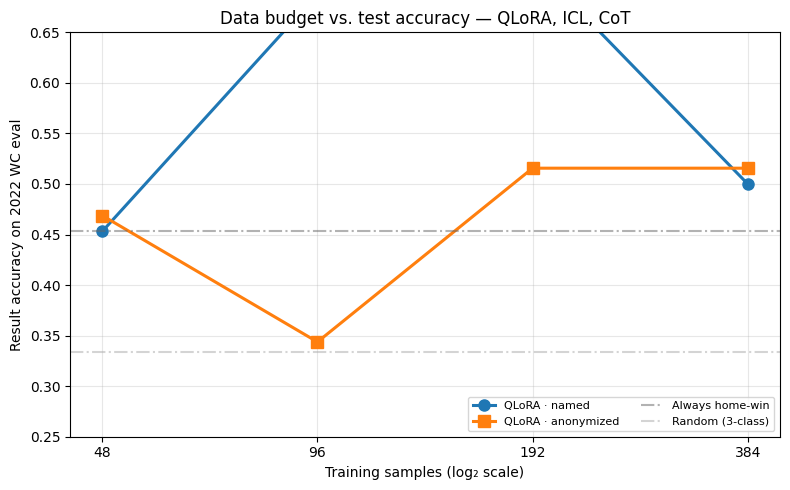

Saved scaling_curve.png


In [16]:
import matplotlib.pyplot as plt

Ns = [48, 96, 192, 384]
named_acc   = [summary[f"n{n}"]['named']['result_accuracy']   for n in Ns]
anon_acc    = [summary[f"n{n}"]['anon']['result_accuracy']    for n in Ns]
overall_acc = [summary[f"n{n}"]['overall']['result_accuracy'] for n in Ns]

# Load ICL/CoT baselines if present
bl = None
for p in ['baseline_metrics.json', '/content/baseline_metrics.json']:
    if os.path.exists(p):
        with open(p) as f:
            bl = json.load(f)
        break

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ns, named_acc, 'o-', color='#1f77b4', linewidth=2.2, markersize=8, label='QLoRA · named')
ax.plot(Ns, anon_acc,  's-', color='#ff7f0e', linewidth=2.2, markersize=8, label='QLoRA · anonymized')

if bl is not None and 'icl' in bl:
    ax.axhline(bl['icl']['named']['result_accuracy'], linestyle='--', color='#1f77b4', alpha=0.55, label='ICL · named')
    ax.axhline(bl['icl']['anon']['result_accuracy'],  linestyle='--', color='#ff7f0e', alpha=0.55, label='ICL · anonymized')
if bl is not None and 'cot' in bl:
    ax.axhline(bl['cot']['named']['result_accuracy'], linestyle=':', color='#1f77b4', alpha=0.7, label='CoT · named')
    ax.axhline(bl['cot']['anon']['result_accuracy'],  linestyle=':', color='#ff7f0e', alpha=0.7, label='CoT · anonymized')

ax.axhline(0.453, linestyle='-.', color='#666', alpha=0.5, label='Always home-win')
ax.axhline(1/3,   linestyle='-.', color='#aaa', alpha=0.5, label='Random (3-class)')

ax.set_xscale('log', base=2)
ax.set_xticks(Ns); ax.set_xticklabels(Ns)
ax.set_xlabel("Training samples (log₂ scale)")
ax.set_ylabel("Result accuracy on 2022 WC eval")
ax.set_title("Data budget vs. test accuracy — QLoRA, ICL, CoT")
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
ax.set_ylim(0.25, 0.65)
plt.tight_layout()
plt.savefig("scaling_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved scaling_curve.png")

## 10. Money figure 2 — prediction-distribution curve

**This is the paper's headline.** ICL predicts home_win 82% of the time, CoT predicts home_win 99% of the time — gradient-free methods collapse to majority class. How quickly does QLoRA escape this collapse as n grows?

Stacked bars show the home/draw/away prediction rates at each n, with dashed lines showing the GT reference. The point where QLoRA's stack starts to look like GT is the point where the model stops being a majority-class classifier.


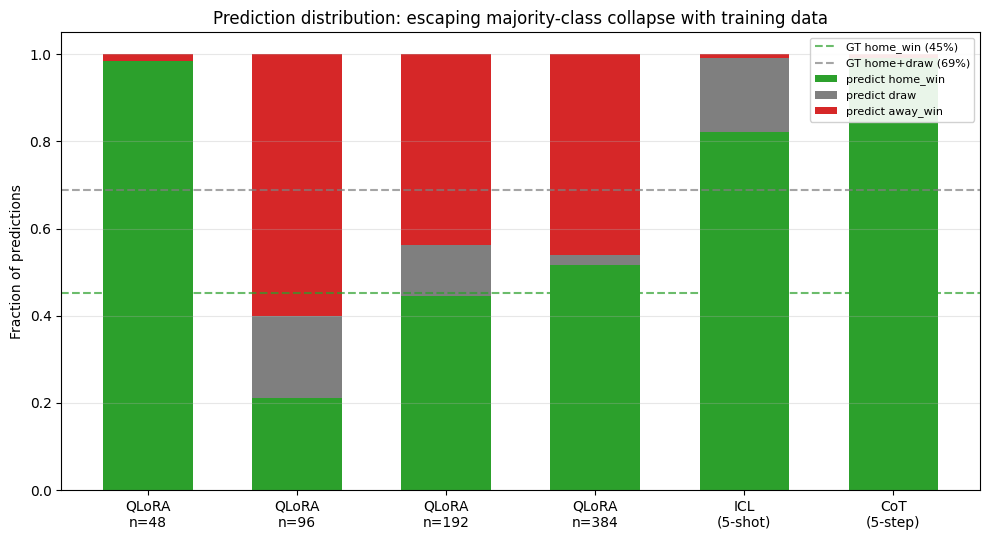

Saved distribution_curve.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Conditions to plot: QLoRA at each n, plus ICL and CoT as reference points
conditions = []
for n in Ns:
    m = summary[f"n{n}"]['overall']
    pd = m['pred_dist']
    total = m['total']
    conditions.append((f"QLoRA\nn={n}",
                       pd['home_win']/total, pd['draw']/total, pd['away_win']/total))

if bl is not None and 'icl' in bl:
    # Recompute prediction rates from per-split metrics if available;
    # but pred_dist may not be in the saved baseline_metrics.
    # Use the known values from the nb3 analysis as fallback.
    pass

# Add reference points based on the analysis we already did
# ICL: 105 home, 22 draw, 1 away out of 128
# CoT: 127 home, 0 draw, 1 away out of 128
conditions.append(("ICL\n(5-shot)", 105/128, 22/128, 1/128))
conditions.append(("CoT\n(5-step)", 127/128, 0/128, 1/128))

# GT reference: 58 home, 30 draw, 40 away out of 128
gt_home, gt_draw, gt_away = 58/128, 30/128, 40/128

labels = [c[0] for c in conditions]
homes  = [c[1] for c in conditions]
draws  = [c[2] for c in conditions]
aways  = [c[3] for c in conditions]

x = np.arange(len(labels))
w = 0.6
ax.bar(x, homes, w, color='#2ca02c', label='predict home_win')
ax.bar(x, draws, w, bottom=homes, color='#7f7f7f', label='predict draw')
ax.bar(x, aways, w, bottom=[h+d for h, d in zip(homes, draws)], color='#d62728', label='predict away_win')

# GT reference lines
ax.axhline(gt_home, linestyle='--', color='#2ca02c', alpha=0.7, linewidth=1.5, label=f'GT home_win ({gt_home*100:.0f}%)')
ax.axhline(gt_home + gt_draw, linestyle='--', color='#7f7f7f', alpha=0.7, linewidth=1.5, label=f'GT home+draw ({(gt_home+gt_draw)*100:.0f}%)')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Fraction of predictions")
ax.set_title("Prediction distribution: escaping majority-class collapse with training data")
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("distribution_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved distribution_curve.png")

## 11. Confusion matrices

One figure, N small 3×3 heatmaps: n=48, n=96, n=192, n=384 QLoRA, plus ICL and CoT as references. Makes the collapse-vs-reasoning contrast unmistakable.


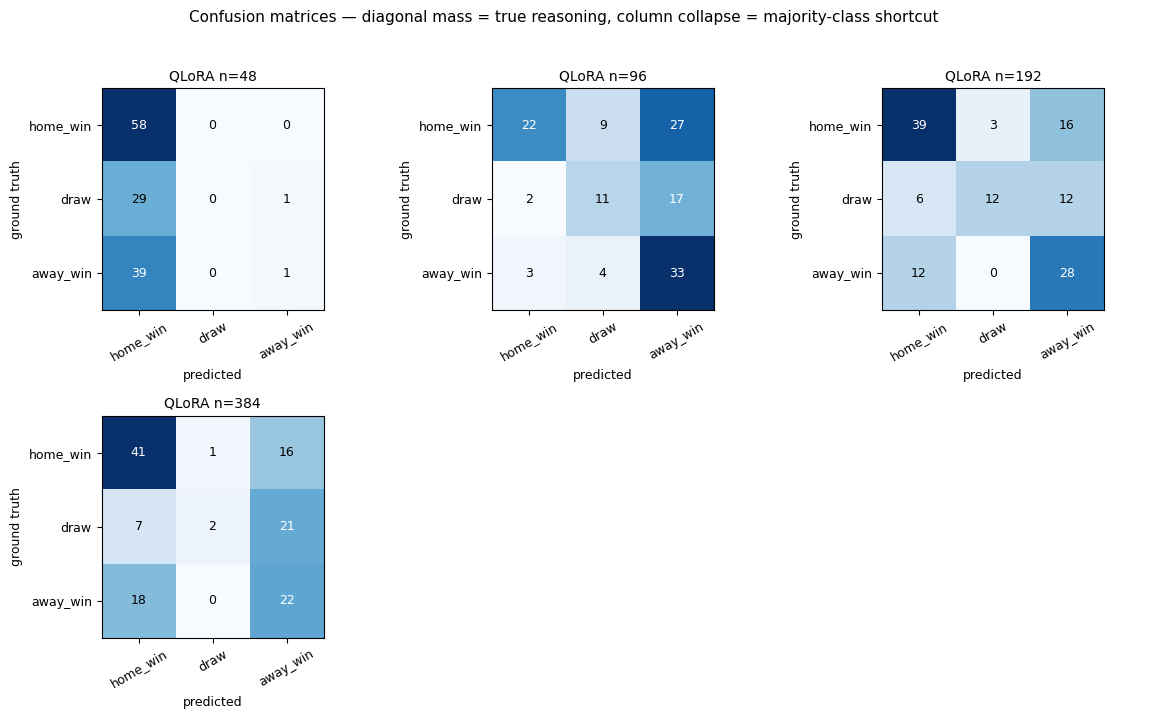

Saved confusion_matrices.png


In [18]:
from itertools import product

def confusion(results, classes=('home_win', 'draw', 'away_win')):
    cm = np.zeros((3, 3), dtype=int)
    idx = {c: i for i, c in enumerate(classes)}
    for r in results:
        gt = r['gt']['result']; pd = r['pred']['result']
        if gt in idx and pd in idx:
            cm[idx[gt], idx[pd]] += 1
    return cm, list(classes)

# Build the set of matrices we want
panels = [('QLoRA n=48', all_results['n48']),
          ('QLoRA n=96', all_results['n96']),
          ('QLoRA n=192', all_results['n192']),
          ('QLoRA n=384', all_results['n384'])]

# Load ICL/CoT raw if available — we'd need the JSON files from nb3/nb3b
for p in ['icl_results.json', '/content/icl_results.json']:
    if os.path.exists(p):
        with open(p) as f:
            panels.append(('ICL (5-shot)', json.load(f)))
        break
for p in ['cot_results_v2.json', '/content/cot_results_v2.json']:
    if os.path.exists(p):
        with open(p) as f:
            panels.append(('CoT (5-step)', json.load(f)))
        break

n_panels = len(panels)
cols = 3
rows = (n_panels + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.5*rows))
axes = np.array(axes).reshape(-1)

for ax, (title, results) in zip(axes, panels):
    cm, cls = confusion(results)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(cls, rotation=30, fontsize=9)
    ax.set_yticklabels(cls, fontsize=9)
    ax.set_xlabel('predicted', fontsize=9)
    ax.set_ylabel('ground truth', fontsize=9)
    ax.set_title(title, fontsize=10)
    for (i, j) in product(range(3), range(3)):
        txt_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=txt_color, fontsize=9)
for ax in axes[n_panels:]:
    ax.axis('off')

plt.suptitle("Confusion matrices — diagonal mass = true reasoning, column collapse = majority-class shortcut",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrices.png")

## 12. Train/val loss curves (overfitting diagnostic)

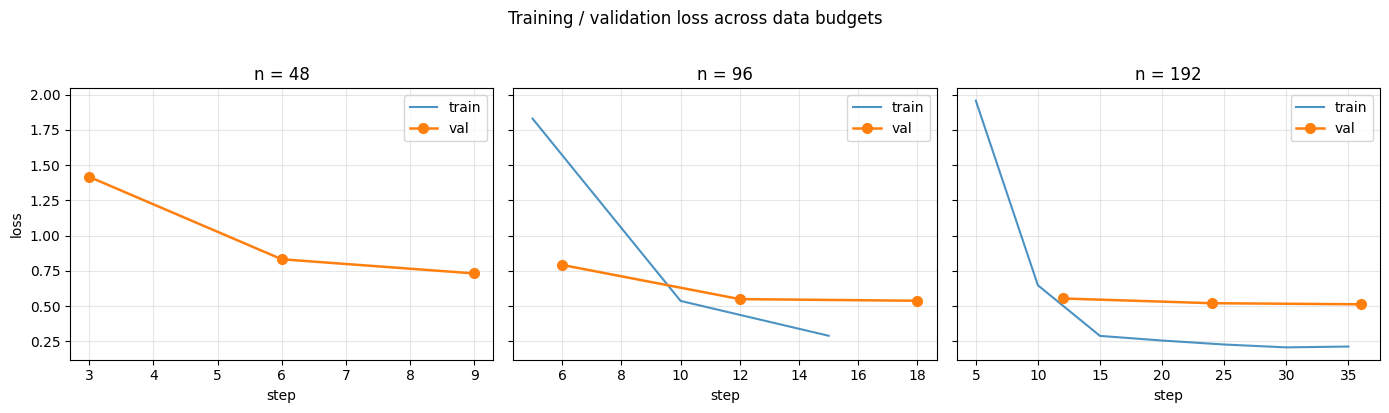

Saved loss_curves.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, n in zip(axes, [48, 96, 192]):
    log_path = f"runs/qlora_n{n}/trainer_log.json"
    if not os.path.exists(log_path):
        ax.text(0.5, 0.5, f"No log for n={n}", ha='center', transform=ax.transAxes)
        continue
    with open(log_path) as f:
        log = json.load(f)
    tr_steps = [e['step'] for e in log if 'loss' in e and 'eval_loss' not in e]
    tr_loss  = [e['loss']  for e in log if 'loss' in e and 'eval_loss' not in e]
    ev_steps = [e['step'] for e in log if 'eval_loss' in e]
    ev_loss  = [e['eval_loss'] for e in log if 'eval_loss' in e]
    ax.plot(tr_steps, tr_loss, linewidth=1.5, alpha=0.8, label='train')
    if ev_steps:
        ax.plot(ev_steps, ev_loss, 'o-', linewidth=1.8, markersize=7, label='val')
    ax.set_title(f"n = {n}")
    ax.set_xlabel("step")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
axes[0].set_ylabel("loss")
plt.suptitle("Training / validation loss across data budgets", y=1.02)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved loss_curves.png")

## 13. Reading the results

**Primary question (collapse escape):** at what n does QLoRA's home_win prediction rate drop from ICL/CoT levels (82–99%) toward the GT rate (45%)? The answer is a single number the paper can report.

**Secondary question (named-vs-anon):** does FT's anon > named pattern hold at all n, or only once n is large enough to meaningfully override pre-training priors? If small-n QLoRA shows no anon advantage, the de-biasing effect needs enough data to kick in, which strengthens the mechanistic claim.

**Tertiary question (crossover with ICL/CoT):** at n=48, does QLoRA underperform ICL/CoT? That would confirm H4 from the proposal — there's a data threshold below which fine-tuning is strictly worse than prompting-only methods. The proposal pre-registered this as a possibility; finding the actual crossover point (if one exists) is a real result.

**Fourth question (loss curves):** if val loss rises while train loss falls on n=48, the small-data regime is memorizing, and the subsequent accuracy gains at larger n come partly from better generalization per example, not just seeing more data.

All four observations can be stated cleanly regardless of the specific numbers. The value of the experiment is the design, not any particular outcome.
